# 13. Debt and stock-flow reconciliation

Reconcile modern Maastricht debt changes with B.9 and the stock-flow adjustment, showing that debt dynamics are not the mirror image of the annual balance.

**Reads**

- `outputs/tables/debt_stock_flow_reconciliation.csv`

**Writes**

- Nothing. The reconciliation table is persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 14

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. The reconciliation

$$\Delta Debt_t = -B_t + SFA_t.$$

The stock-flow adjustment absorbs everything that changes debt without passing
through the annual balance: financial-asset transactions, valuation effects,
timing differences and statistical adjustments. It is computed here as a residual
check on the persisted table.

In [2]:
debt = pd.read_csv(TABLES / 'debt_stock_flow_reconciliation.csv')
debt_columns = [
    'year',
    'balance_m_eur',
    'debt_change_m_eur',
    'stock_flow_adjustment_m_eur',
    'debt_pct_gdp',
    'stock_flow_adjustment_pct_gdp',
    'reconciliation_error_m_eur',
]
general = debt.loc[debt['sector'].eq('general_government') & debt['year'].ge(2010), debt_columns]
display(general.round(3))
print('max |reconciliation residual| (M EUR):', float(debt['reconciliation_error_m_eur'].abs().max()))

,year,balance_m_eur,debt_change_m_eur,stock_flow_adjustment_m_eur,debt_pct_gdp,stock_flow_adjustment_pct_gdp,reconciliation_error_m_eur
40,2010,-20537.136,26028.501,5491.366,99.885,3.053,0
41,2011,-13624.044,21391.564,7767.520,114.024,4.405,0
42,2012,-10453.474,15702.278,5248.803,128.603,3.114,0
43,2013,-8898.289,6566.624,-2331.665,130.841,-1.366,0
44,2014,-12751.535,6077.978,-6673.557,132.453,-3.853,0
45,2015,-8025.986,5654.737,-2371.249,131.023,-1.322,0
46,2016,-3622.061,9448.677,5826.617,131.180,3.126,0
47,2017,-5869.557,1903.873,-3965.684,126.029,-2.028,0
48,2018,-872.825,1878.638,1005.813,121.112,0.491,0
49,2019,248.993,766.381,1015.374,116.110,0.473,0


max |reconciliation residual| (M EUR): 0.0


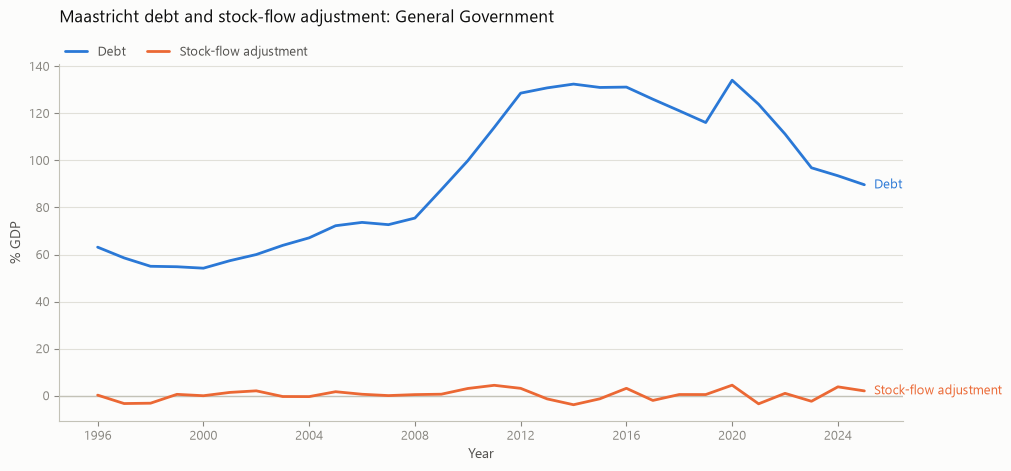

In [3]:
figure = figures.debt_and_stock_flow(debt)

## 2. What moves the debt ratio

The columns below split each annual debt change into minus the balance and the
stock-flow adjustment. In several years the adjustment is the larger term, which
is the point of running the reconciliation at all.

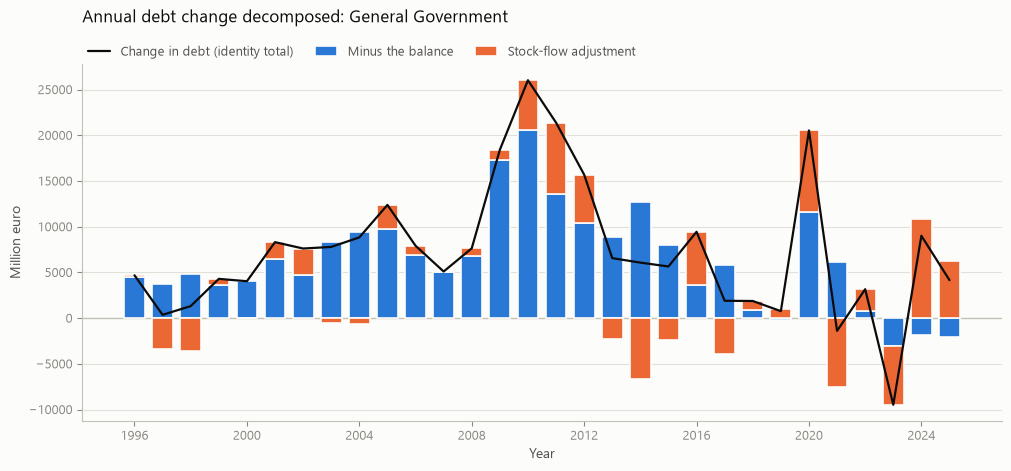

In [4]:
figure = figures.debt_change_decomposition(debt)

In [5]:
general_government = debt.loc[debt['sector'].eq('general_government')].copy()
general_government['sfa_share_abs_debt_change'] = (
    general_government['stock_flow_adjustment_m_eur'].abs()
    / general_government['debt_change_m_eur'].abs()
)
display(
    general_government.loc[
        general_government['sfa_share_abs_debt_change'].gt(1.0),
        ['year', 'balance_m_eur', 'debt_change_m_eur', 'stock_flow_adjustment_m_eur'],
    ].round(1)
)

,year,balance_m_eur,debt_change_m_eur,stock_flow_adjustment_m_eur
27,1997,-3792.0,367.0,-3425.0
28,1998,-4885.7,1321.0,-3564.7
44,2014,-12751.5,6078.0,-6673.6
47,2017,-5869.6,1903.9,-3965.7
49,2019,249.0,766.4,1015.4
51,2021,-6117.0,-1389.2,-7506.2
54,2024,1862.5,9012.8,10875.4
55,2025,2058.6,4160.8,6219.5


## Interpretation limits

1. The stock-flow adjustment is a **residual category**, not a behavioural
   variable. A large value is a signal to consult the source documentation, not
   an anomaly by itself.
2. Reconciliation is available for the **modern regime only**, where debt and
   adjustment series are published on a consistent basis.
3. The debt ratio changes with **nominal GDP** as well as with debt, so a falling
   ratio does not imply falling debt.

---

[Previous: 12. Fixed-capital-formation diagnostic](12_investment_diagnostic.ipynb) | [Next: 14. Descriptive macroeconomic co-movement](14_macroeconomic_comovement.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```